# **How do annual members and casual riders use Cyclistic bikes differently?**




Project Title : **Cyclistic bike-share analysis**                                                                   
Data Analyst: **Vansh**

Company : **Cyclistic** (Chicago)

Client : **Cyclistic Marketing Team**

Sponsor : **Lily Moreno** (Director of Marketing)



**Purpose**:
The director of marketing believes the company’s future success depends on maximizing the number of annual memberships. Therefore, your team wants to understand how casual riders and annual members use Cyclistic bikes differently. From these insights, your team will design a new marketing strategy to convert casual riders into annual members.


Overview of the ***Notebook***

This notebooke includes includes all important steps for analysis


1.   Prepare the data for exploration
2.   Process the data from dirty to clean
3.   Analyse the data to answer the questions

Notebook **Output** : After finding the insights and trends from member vs casual riders , Cyclistic Marketing Team can make more better decisions and data driven decision.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Combining all files together

In [ ]:
directory_path = "/content/drive/MyDrive/cyclistic_project_mar26/12_months_dataset/"
for file_name in os.listdir(directory_path):
  print(file_name)
all_files = glob.glob(os.path.join(directory_path, "*.csv"))
data = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
df = pd.DataFrame(data)

202503-divvy-tripdata.csv
202504-divvy-tripdata.csv
202505-divvy-tripdata.csv
202506-divvy-tripdata.csv
202507-divvy-tripdata.csv
202508-divvy-tripdata.csv
202509-divvy-tripdata.csv
202510-divvy-tripdata.csv
202511-divvy-tripdata.csv
202512-divvy-tripdata.csv
202602-divvy-tripdata.csv
202601-divvy-tripdata.csv


# Prepare data


In [ ]:
print("Total files number :", len(all_files))

Total files number : 12


In [ ]:
print("Columns names : " ,df.columns)

Columns names :  Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')


In [ ]:
print(df.shape)

(5601662, 13)


In [ ]:
print("Null values in all columns" ,df.isnull().sum())

Null values in all columns ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1192515
start_station_id      1192515
end_station_name      1254439
end_station_id        1254439
start_lat                   0
start_lng                   0
end_lat                  5742
end_lng                  5742
member_casual               0
dtype: int64


In [ ]:
print(df.dtypes)

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


In [ ]:
print(df.head())

            ride_id  rideable_type               started_at  \
0  16CBE9844D401954  electric_bike  2025-03-18 08:39:20.065   
1  1CB408029E2B5F74  electric_bike  2025-03-24 16:04:22.239   
2  7B6A76CD0F204D08  electric_bike  2025-03-10 16:06:19.708   
3  4F7084E3D75CDE31  electric_bike  2025-03-21 14:28:14.579   
4  E419A570A5A0475B  electric_bike  2025-03-14 17:54:14.484   

                  ended_at start_station_name start_station_id  \
0  2025-03-18 08:51:37.633                NaN              NaN   
1  2025-03-24 16:27:41.347                NaN              NaN   
2  2025-03-10 16:29:17.457                NaN              NaN   
3  2025-03-21 14:35:06.160                NaN              NaN   
4  2025-03-14 18:17:53.254                NaN              NaN   

                end_station_name end_station_id  start_lat  start_lng  \
0        Canal St & Jackson Blvd          13138      41.91     -87.67   
1  Albany Ave & Bloomingdale Ave          15655      41.86     -87.68   
2  Al

In [ ]:
print(df.info)

<bound method DataFrame.info of                   ride_id  rideable_type               started_at  \
0        16CBE9844D401954  electric_bike  2025-03-18 08:39:20.065   
1        1CB408029E2B5F74  electric_bike  2025-03-24 16:04:22.239   
2        7B6A76CD0F204D08  electric_bike  2025-03-10 16:06:19.708   
3        4F7084E3D75CDE31  electric_bike  2025-03-21 14:28:14.579   
4        E419A570A5A0475B  electric_bike  2025-03-14 17:54:14.484   
...                   ...            ...                      ...   
5601657  9EA0EE1BE22F4057  electric_bike  2026-01-12 16:07:01.812   
5601658  A0FBF309926C62D6  electric_bike  2026-01-31 10:40:40.883   
5601659  304567F6576492D8  electric_bike  2026-01-20 09:07:10.405   
5601660  0F610B304B95246A  electric_bike  2026-01-22 16:28:18.534   
5601661  A3C67242DC777397  electric_bike  2026-01-22 08:33:39.424   

                        ended_at          start_station_name start_station_id  \
0        2025-03-18 08:51:37.633                         N

# Process Data

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.isnull().sum())

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1192515
start_station_id      1192515
end_station_name      1254439
end_station_id        1254439
start_lat                   0
start_lng                   0
end_lat                  5742
end_lng                  5742
member_casual               0
dtype: int64


Remove the rows where end_lng and end_lat is null

In [ ]:
print("Deleteting null values in columns end_lng and end_lat")
df.dropna(subset=['end_lng', 'end_lat'], inplace=True)


Deleteting null values in columns end_lng and end_lat


In [ ]:
print(df['rideable_type'].unique())
print(df['member_casual'].unique())

['electric_bike' 'classic_bike']
['member' 'casual']


In [ ]:
print(df.dtypes)

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


Converting the datatypes of started_at and ended_at columns into datetime


In [ ]:
print(" sarted_at and end_at columns data type is change successfully  ")
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

 sarted_at and end_at columns data type is change successfully  


In [ ]:
print(df.dtypes)

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object


Creating the new columns for analysis


In [ ]:
df['ride_length'] = df['ended_at'] - df['started_at']
df['month'] = df['started_at'].dt.month_name()
df['day_of_week'] = df['started_at'].dt.day_name()
df['hour'] = df['started_at'].dt.hour

In [ ]:
print(df['month'].unique())
print(df['hour'].unique())
print(df['day_of_week'].unique())

['March' 'February' 'April' 'May' 'June' 'July' 'August' 'September'
 'October' 'November' 'December' 'January']
[ 8 16 14 17 19 21  9  7 12 18 22 10 15 13 11  4  1 20  6 23  0  5  2  3]
['Tuesday' 'Monday' 'Friday' 'Saturday' 'Thursday' 'Wednesday' 'Sunday']


In [ ]:
print("removing the rows where ride_length is negative")


removing the rows where ride_length is negative


In [ ]:
print(df.dtypes)

ride_id                        object
rideable_type                  object
started_at             datetime64[ns]
ended_at               datetime64[ns]
start_station_name             object
start_station_id               object
end_station_name               object
end_station_id                 object
start_lat                     float64
start_lng                     float64
end_lat                       float64
end_lng                       float64
member_casual                  object
ride_length           timedelta64[ns]
month                          object
day_of_week                    object
hour                            int32
dtype: object


In [ ]:
print(df.isnull().sum())

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1192515
start_station_id      1192515
end_station_name      1248697
end_station_id        1248697
start_lat                   0
start_lng                   0
end_lat                     0
end_lng                     0
member_casual               0
ride_length                 0
month                       0
day_of_week                 0
hour                        0
dtype: int64


## Analyze Phase (Descriptive analysis)

Quick calculation for finding the diffrence between the members and casual riders

In [ ]:
counts = df['member_casual'].value_counts()
percentage = df['member_casual'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percentage.round(3)})
print(summary)

                 Count  Percentage
member_casual                     
member         3587143      64.103
casual         2008777      35.897


In [ ]:
print("-" * 10, "Mean ride_length for Casual and members riders" , "-" * 10)
pivot_mean = df.pivot_table(values="ride_length",index="member_casual",aggfunc="mean")
print(pivot_mean)


---------- Mean ride_length for Casual and members riders ----------
                            ride_length
member_casual                          
casual        0 days 00:19:12.003784311
member        0 days 00:12:01.985857039


In [ ]:
print("-" * 10, "Max ride_length for Casual and members riders" , "-" * 10)
pivot_max = df.pivot_table(values="ride_length",index="member_casual",aggfunc="max")
print(pivot_max)

---------- Max ride_length for Casual and members riders ----------
                         ride_length
member_casual                       
casual        1 days 00:59:58.064000
member        1 days 00:59:57.959000


In [ ]:
print("-" * 10, "Min ride_length for Casual and members riders" , "-" * 10)
pivot_min = df.pivot_table(values="ride_length",index="member_casual",aggfunc="min")
print(pivot_min)

---------- Min ride_length for Casual and members riders ----------
                           ride_length
member_casual                         
casual        -1 days +23:08:57.138000
member        -1 days +23:05:12.312000


In [ ]:
print("-" * 10, "Mode day of week  for Casual and members riders" , "-" * 10)
pivot_mode = df.pivot_table(values="day_of_week",index="member_casual",aggfunc=lambda x:x.mode())
print(pivot_mode)

---------- Mode day of week  for Casual and members riders ----------
              day_of_week
member_casual            
casual           Saturday
member           Thursday


In [ ]:
print("-" * 10, "Busiest hour for Casual and members riders" , "-" * 10)
pivot_hour = df.pivot_table(values="hour",index="member_casual",aggfunc=lambda x:x.mode())
print(pivot_hour)

---------- Busiest hour for Casual and members riders ----------
               hour
member_casual      
casual           17
member           17


error : some ride length are in  negative because of some technical error


In [ ]:
negative_rides = df[df['ride_length'] < pd.Timedelta(0)]
print(len(negative_rides))

29


In [ ]:
print(df.shape)

(5595920, 18)


In [ ]:
df = df[df['ride_length'] > pd.Timedelta(0)]


In [ ]:
print(df.shape)

(5595891, 18)


**Season and weeekly pattren**

Highest riders by Day (member vs casual)

In [ ]:
group_by = df.groupby(['day_of_week' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False)
print(group_by)


member_casual  casual  member
day_of_week                  
Thursday       258354  578423
Tuesday        227706  574370
Wednesday      222776  559322
Friday         322027  533858
Monday         229921  506265
Saturday       414895  452286
Sunday         333098  382619


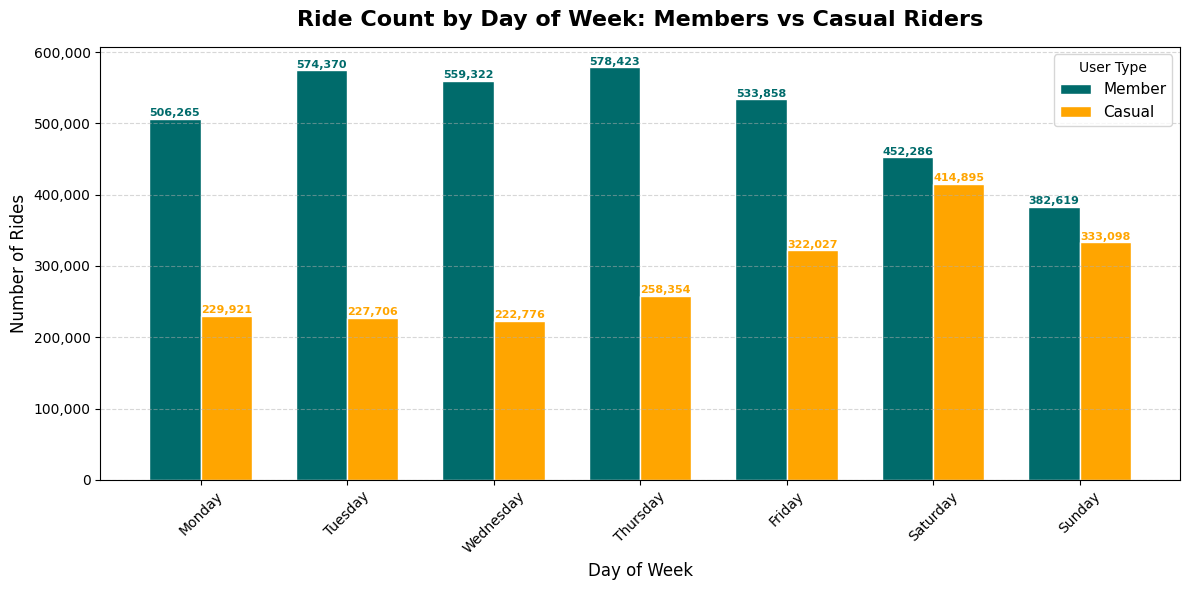

In [ ]:

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

group_by = df.groupby(['day_of_week', 'member_casual'])['ride_id'].count().unstack()
group_by = group_by.reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(group_by.index))
width = 0.35

bars1 = ax.bar(x - width/2, group_by['member'], width,
               color='#006B6B', label='Member', edgecolor='white')
bars2 = ax.bar(x + width/2, group_by['casual'], width,
               color='#FFA500', label='Casual', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8, color='#006B6B', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8, color='#FFA500', fontweight='bold')

ax.set_title('Ride Count by Day of Week: Members vs Casual Riders',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=45)
ax.legend(title='User Type', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Highest riders by month (member vs casual)

In [ ]:
month_groupby = df.groupby(['month' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False)
print(month_groupby)

member_casual  casual  member
month                        
August         337258  452352
September      264773  449200
July           322502  439975
October        223579  421926
June           291135  386705
May            182275  319751
April          108982  262097
November        98859  257311
March           85668  212230
February        41087  160248
January         24654  112930
December        28005  112418


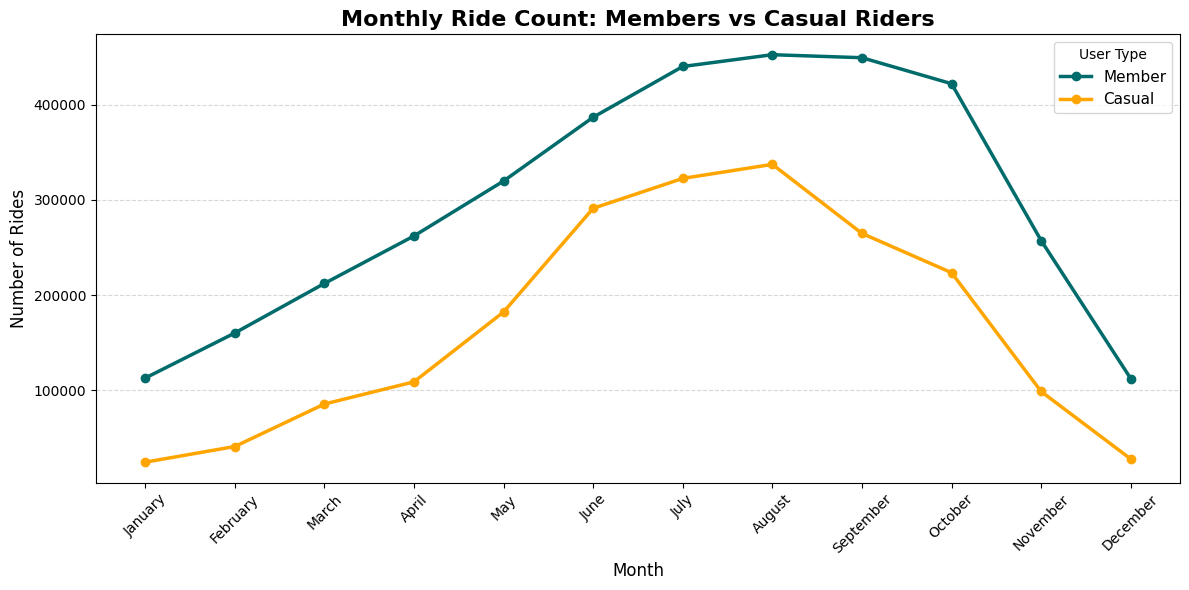

In [ ]:
import matplotlib.pyplot as plt

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']


month_groupby = df.groupby(['month', 'member_casual'])['ride_id'].count().unstack()
month_groupby = month_groupby.reindex(month_order).dropna()


plt.figure(figsize=(12, 6))
plt.plot(month_groupby.index, month_groupby['member'],
         marker='o', linewidth=2.5, color='#006B6B', label='Member')
plt.plot(month_groupby.index, month_groupby['casual'],
         marker='o', linewidth=2.5, color='#FFA500', label='Casual')

plt.title('Monthly Ride Count: Members vs Casual Riders', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='User Type', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()




Members vs Casual by hour

In [ ]:
hour_groupby = df.groupby(['hour' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False)
print(hour_groupby)

member_casual  casual  member
hour                         
17             191586  386690
16             177034  338820
18             164660  298883
8               70875  259985
15             155205  239885
19             122324  206560
7               49969  202006
12             129244  191559
14             139821  189708
13             132800  186577
11             109513  169061
9               71149  167826
10              85709  144055
20              88209  143253
21              75525  111718
6               26852  101944
22              63570   81393
23              46130   50694
5               11576   34816
0               38984   32604
1               24887   20118
2               16656   12163
4                7285    8889
3                9214    7936


Member and casul riders by ridertype

member_casual   casual   member
rideable_type                  
electric_bike  1337352  2307780
classic_bike    671425  1279363


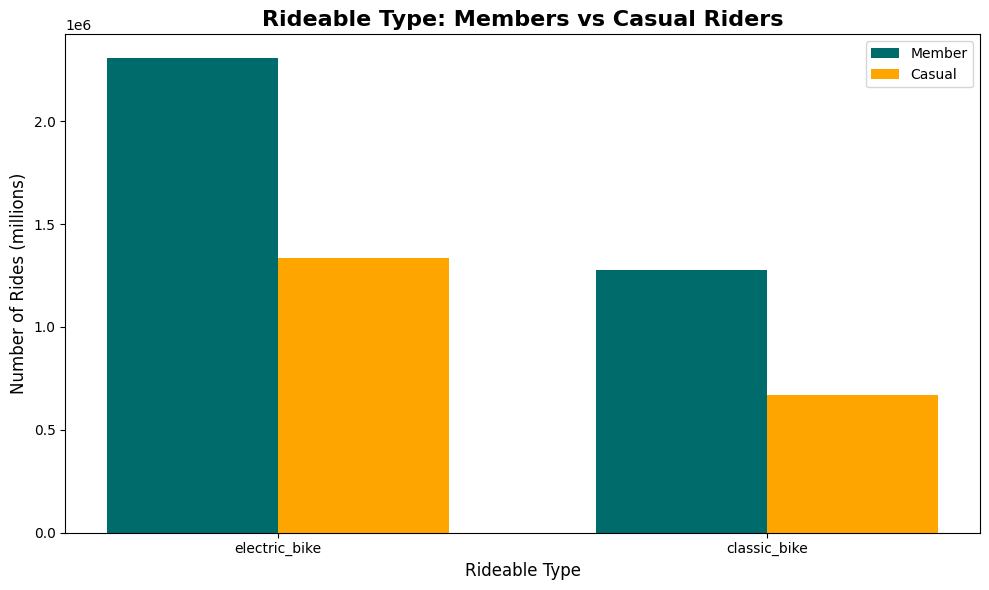

In [ ]:
ridertype_groupby = df.groupby(['rideable_type' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False)
print(ridertype_groupby)

plt.figure(figsize=(10, 6))

bar_width = 0.35
r1 = np.arange(len(ridertype_groupby.index))
r2 = [x + bar_width for x in r1]

plt.bar(r1, ridertype_groupby['member'], color='#006B6B', width=bar_width, label='Member')
plt.bar(r2, ridertype_groupby['casual'], color='#FFA500', width=bar_width, label='Casual')

plt.title('Rideable Type: Members vs Casual Riders', fontsize=16, fontweight='bold')
plt.xlabel('Rideable Type', fontsize=12)
plt.ylabel('Number of Rides (millions)', fontsize=12)

plt.xticks([r + bar_width/2 for r in range(len(ridertype_groupby.index))], ridertype_groupby.index)

plt.legend()
plt.tight_layout()
plt.show()

Creating the new column to compare the weekend and weekdays behaviour

In [ ]:
df['day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

print(df[['day_of_week', 'day_type', 'member_casual']].head(10))

  day_of_week day_type member_casual
0     Tuesday  Weekday        member
1      Monday  Weekday        member
2      Monday  Weekday        member
3      Friday  Weekday        member
4      Friday  Weekday        casual
5      Monday  Weekday        member
6     Tuesday  Weekday        member
7    Saturday  Weekend        member
8    Thursday  Weekday        member
9      Friday  Weekday        member


In [ ]:
daytype_groupby = df.groupby(['day_type' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False)
print(daytype_groupby)

member_casual   casual   member
day_type                       
Weekday        1260784  2752238
Weekend         747993   834905


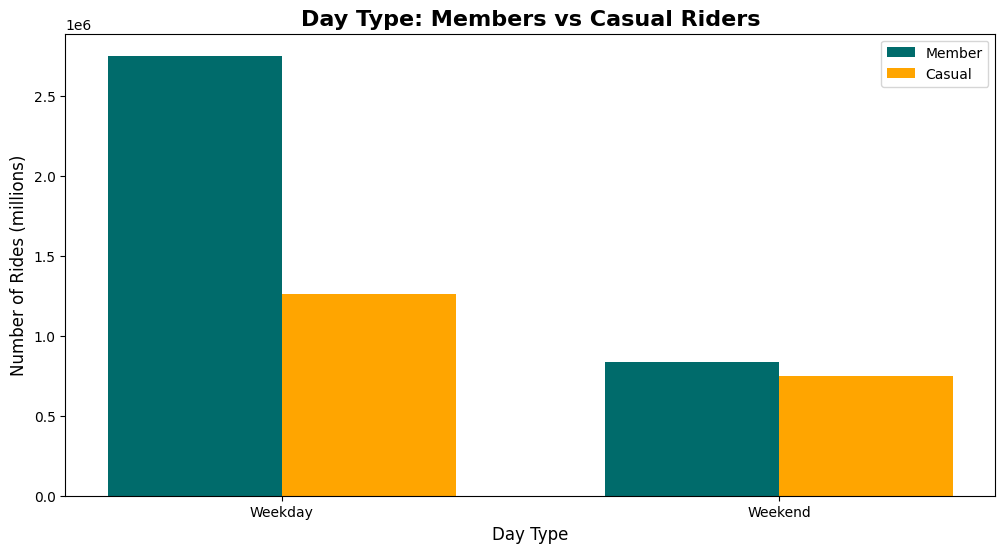

In [ ]:
import numpy as np

plt.figure(figsize=(12, 6))

bar_width = 0.35

r1 = np.arange(len(daytype_groupby.index))
r2 = [x + bar_width for x in r1]

plt.bar(r1, daytype_groupby['member'], color='#006B6B', width=bar_width, label='Member')
plt.bar(r2, daytype_groupby['casual'], color='#FFA500', width=bar_width, label='Casual')

plt.title('Day Type: Members vs Casual Riders', fontsize=16, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Rides (millions)', fontsize=12)

plt.xticks([r + bar_width/2 for r in range(len(daytype_groupby.index))], daytype_groupby.index)

plt.legend()
plt.savefig("Day Type: Members vs Casual Riders.png")
plt.show()

## Understanding the station behaviours

number one starting station for all riders

In [ ]:
overall_number_one_start_station = df['start_station_name'].value_counts().head(1)
print( overall_number_one_start_station )


start_station_name
DuSable Lake Shore Dr & Monroe St    39775
Name: count, dtype: int64


number one start station for casual riders

In [ ]:
casual_number_one_start_station = df.groupby(['start_station_name' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='casual', ascending=False).head(1)
print(casual_number_one_start_station)

member_casual                       casual  member
start_station_name                                
DuSable Lake Shore Dr & Monroe St  31405.0  8370.0


number one station for the memeber riders

In [ ]:
member_number_one_start_station = df.groupby(['start_station_name' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False).head(1)
print(member_number_one_start_station)

member_casual             casual   member
start_station_name                       
Kingsbury St & Kinzie St  8912.0  28131.0


overall number one end station

In [ ]:
overall_number_one_end_station = df['end_station_name'].value_counts().head(1)
print( overall_number_one_end_station )


end_station_name
DuSable Lake Shore Dr & Monroe St    38220
Name: count, dtype: int64


number one end station for the casual riders

In [ ]:
casual_number_one_end_station = df.groupby(['end_station_name' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='casual', ascending=False).head(1)
print(casual_number_one_end_station)

member_casual                       casual  member
end_station_name                                  
DuSable Lake Shore Dr & Monroe St  29320.0  8900.0


number one end station for member riders

In [ ]:
member_number_one_end_station = df.groupby(['end_station_name' , 'member_casual'])['ride_id'].count().unstack().sort_values(by='member', ascending=False).head(1)
print(member_number_one_end_station)

member_casual             casual   member
end_station_name                         
Kingsbury St & Kinzie St  8193.0  28313.0


## Share phase

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans', # Changed from 'Arial'
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Your brand colors
MEMBER_COLOR = '#006B6B'
CASUAL_COLOR = '#FFA500'

print("Style set ✅")

Style set ✅


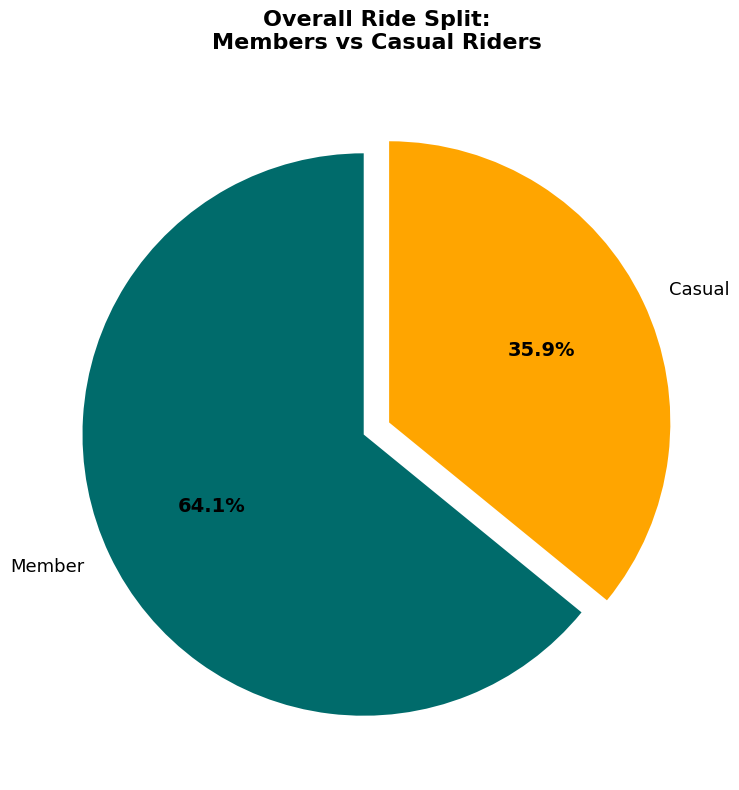

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(8, 8))

counts = df['member_casual'].value_counts()
colors = [MEMBER_COLOR, CASUAL_COLOR]
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    counts,
    labels=['Member', 'Casual'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 13}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax.set_title('Overall Ride Split:\nMembers vs Casual Riders',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/01_member_vs_casual_split.png',
            #dpi=150, bbox_inches='tight')
plt.show()

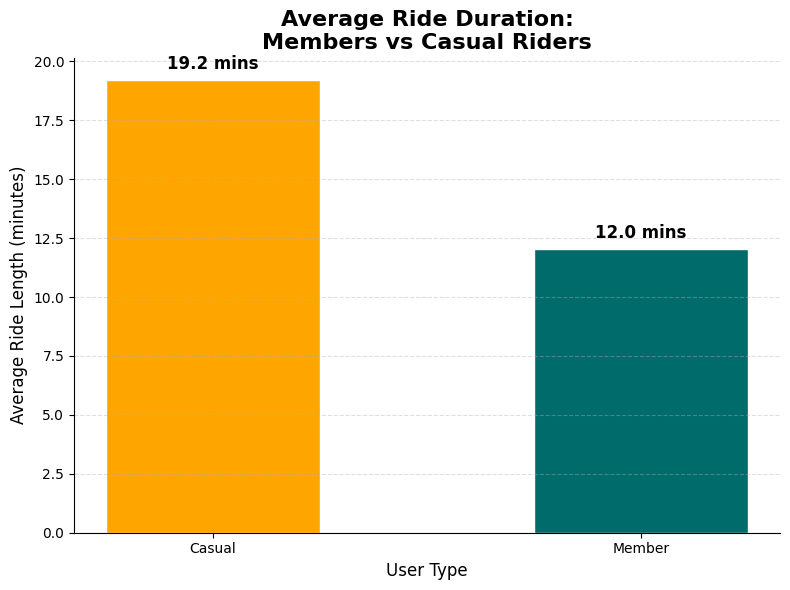

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(8, 6))

avg_duration = df.groupby('member_casual')['ride_length'].mean().dt.total_seconds() / 60
avg_duration.index = ['Casual', 'Member']

bars = ax.bar(avg_duration.index, avg_duration.values,
              color=[CASUAL_COLOR, MEMBER_COLOR],
              width=0.5, edgecolor='white')

# Add value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f} mins',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Average Ride Duration:\nMembers vs Casual Riders')
ax.set_xlabel('User Type')
ax.set_ylabel('Average Ride Length (minutes)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/02_avg_ride_duration.png',
 #           dpi=150, bbox_inches='tight')
plt.show()

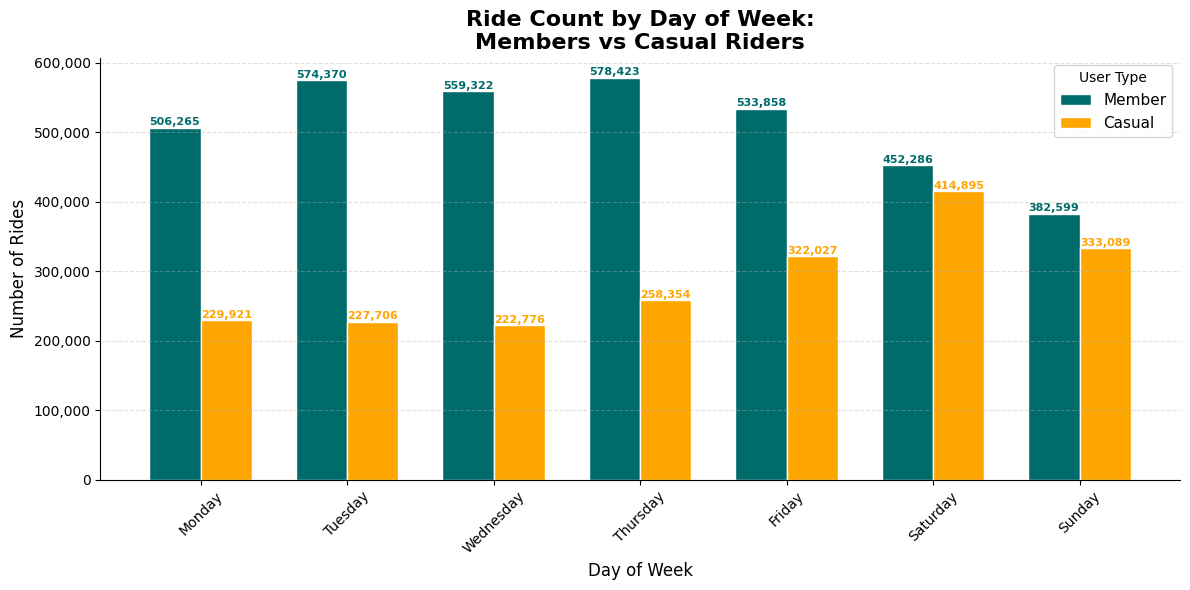

In [ ]:
# @title
import numpy as np

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

day_data = df.groupby(['day_of_week', 'member_casual'])['ride_id'].count().unstack()
day_data = day_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(day_order))
width = 0.35

bars1 = ax.bar(x - width/2, day_data['member'], width,
               color=MEMBER_COLOR, label='Member', edgecolor='white')
bars2 = ax.bar(x + width/2, day_data['casual'], width,
               color=CASUAL_COLOR, label='Casual', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=MEMBER_COLOR)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=CASUAL_COLOR)

ax.set_title('Ride Count by Day of Week:\nMembers vs Casual Riders')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Rides')
ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=45)
ax.legend(title='User Type', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/03_rides_by_day.png',
 #           dpi=150, bbox_inches='tight')
plt.show()

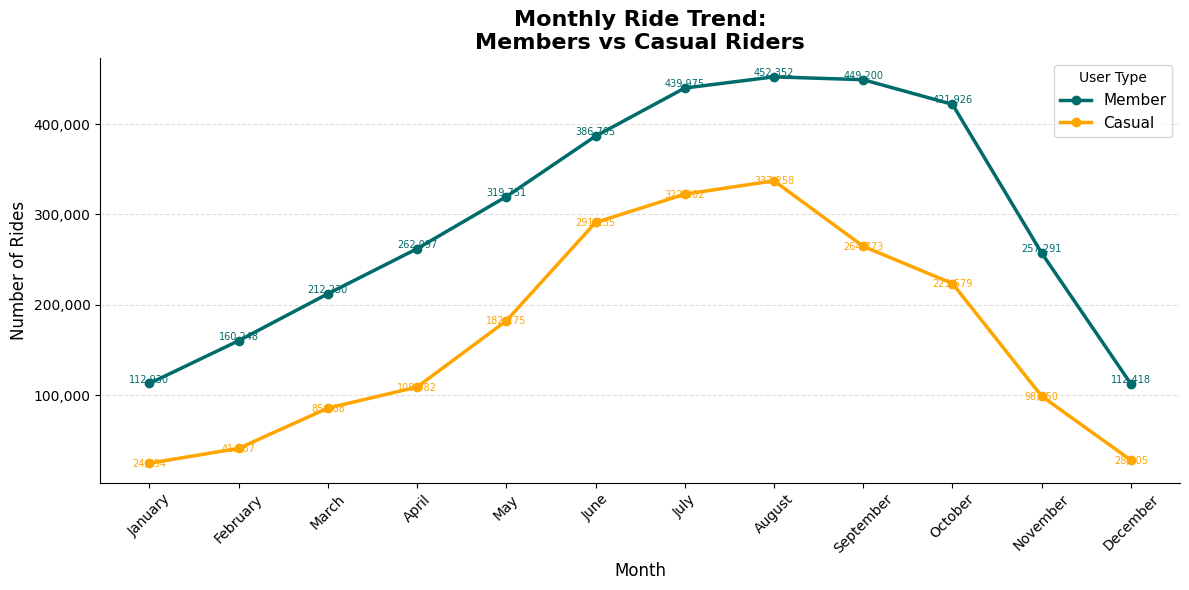

In [ ]:
# @title

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_data = df.groupby(['month', 'member_casual'])['ride_id'].count().unstack()
month_data = month_data.reindex(month_order).dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(month_data.index, month_data['member'],
        marker='o', linewidth=2.5, color=MEMBER_COLOR, label='Member')
ax.plot(month_data.index, month_data['casual'],
        marker='o', linewidth=2.5, color=CASUAL_COLOR, label='Casual')

# Add value labels on each point
for i, (m, c) in enumerate(zip(month_data['member'], month_data['casual'])):
    ax.text(i, m + 1000, f'{int(m):,}', ha='center', fontsize=7, color=MEMBER_COLOR)
    ax.text(i, c - 4000, f'{int(c):,}', ha='center', fontsize=7, color=CASUAL_COLOR)

ax.set_title('Monthly Ride Trend:\nMembers vs Casual Riders')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(len(month_data.index)))
ax.set_xticklabels(month_data.index, rotation=45)
ax.legend(title='User Type', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/04_monthly_trend.png',
 #           dpi=150, bbox_inches='tight')
plt.show()

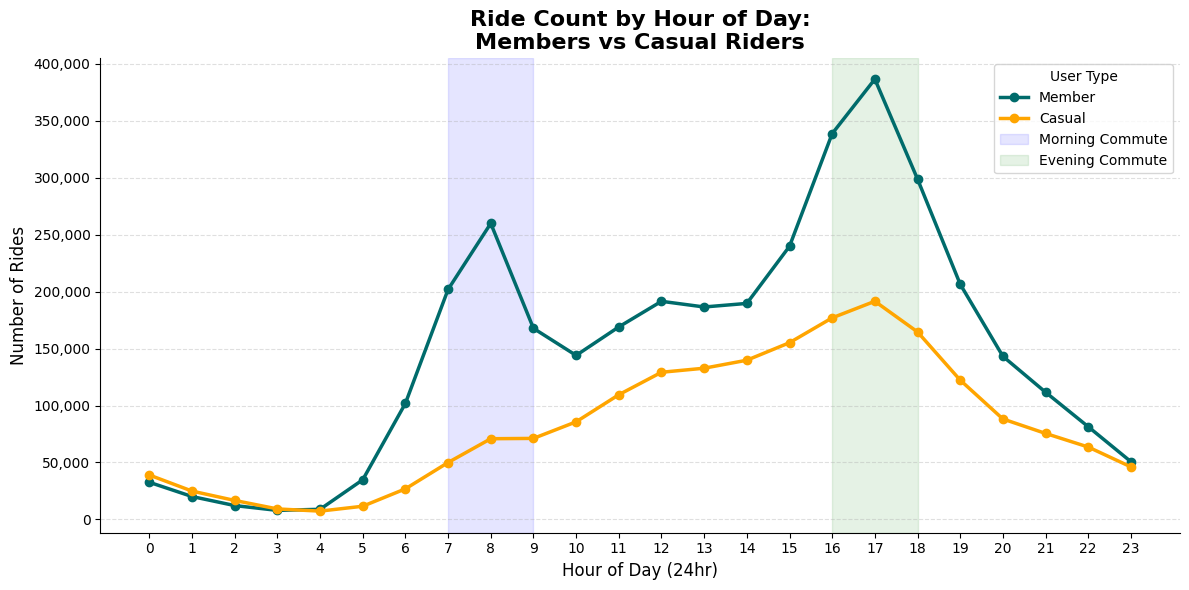

In [ ]:
# @title
hour_data = df.groupby(['hour', 'member_casual'])['ride_id'].count().unstack()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(hour_data.index, hour_data['member'],
        marker='o', linewidth=2.5, color=MEMBER_COLOR, label='Member')
ax.plot(hour_data.index, hour_data['casual'],
        marker='o', linewidth=2.5, color=CASUAL_COLOR, label='Casual')

# Highlight commute hours
ax.axvspan(7, 9, alpha=0.1, color='blue', label='Morning Commute')
ax.axvspan(16, 18, alpha=0.1, color='green', label='Evening Commute')

ax.set_title('Ride Count by Hour of Day:\nMembers vs Casual Riders')
ax.set_xlabel('Hour of Day (24hr)')
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(0, 24))
ax.legend(title='User Type', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/05_rides_by_hour.png',
 #           dpi=150, bbox_inches='tight')
plt.show()

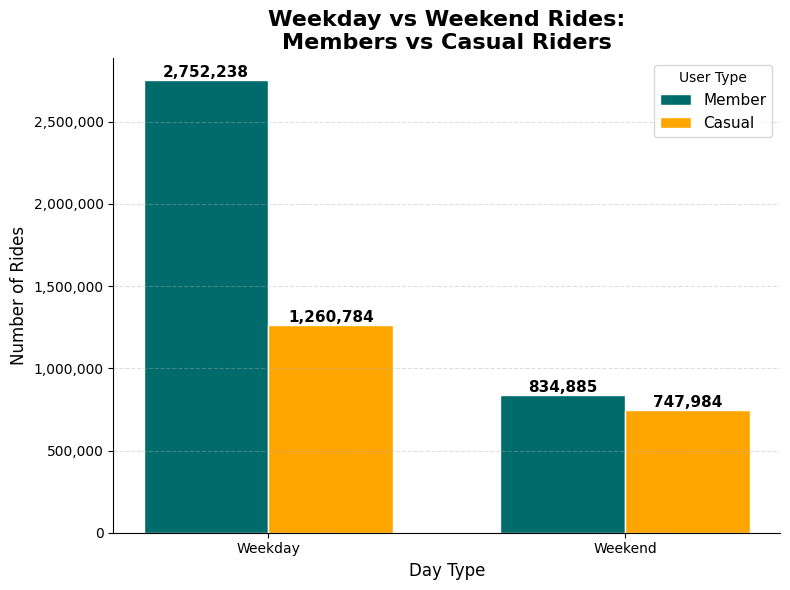

In [ ]:
# @title
day_type_data = df.groupby(['day_type', 'member_casual'])['ride_id'].count().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(day_type_data.index))
width = 0.35

bars1 = ax.bar(x - width/2, day_type_data['member'], width,
               color=MEMBER_COLOR, label='Member', edgecolor='white')
bars2 = ax.bar(x + width/2, day_type_data['casual'], width,
               color=CASUAL_COLOR, label='Casual', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center',
            va='bottom', fontweight='bold', fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center',
            va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Weekday vs Weekend Rides:\nMembers vs Casual Riders')
ax.set_xlabel('Day Type')
ax.set_ylabel('Number of Rides')
ax.set_xticks(x)
ax.set_xticklabels(['Weekday', 'Weekend'])
ax.legend(title='User Type', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/06_weekday_vs_weekend.png',
 #           dpi=150, bbox_inches='tight')
plt.show()

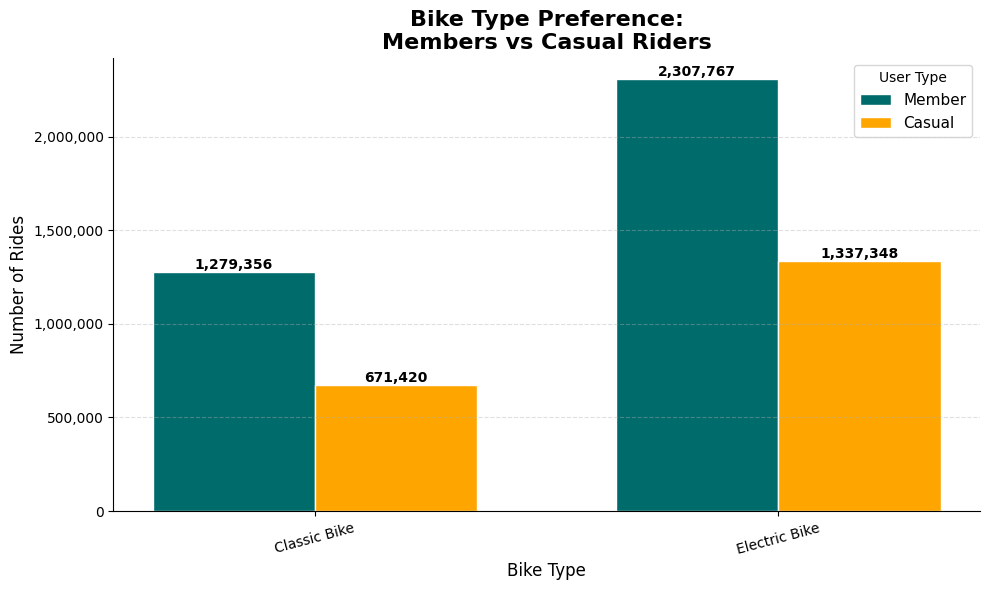

In [ ]:
# @title
bike_data = df.groupby(['rideable_type', 'member_casual'])['ride_id'].count().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(bike_data.index))
width = 0.35

bars1 = ax.bar(x - width/2, bike_data['member'], width,
               color=MEMBER_COLOR, label='Member', edgecolor='white')
bars2 = ax.bar(x + width/2, bike_data['casual'], width,
               color=CASUAL_COLOR, label='Casual', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center',
            va='bottom', fontweight='bold', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center',
            va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Bike Type Preference:\nMembers vs Casual Riders')
ax.set_xlabel('Bike Type')
ax.set_ylabel('Number of Rides')
ax.set_xticks(x)
ax.set_xticklabels(['Classic Bike', 'Electric Bike'], rotation=15)
ax.legend(title='User Type', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/cyclistic_project/visuals/07_bike_type_preference.png',
 #           dpi=150, bbox_inches='tight')
plt.show()